## Vertical sample arrangement

<class 'numpy.ndarray'>
areas: 
 [6.7 4.6 3.5 5.5]
prices: 
 [[9.1]
 [5.9]
 [4.6]
 [6.7]]
data_size:  4


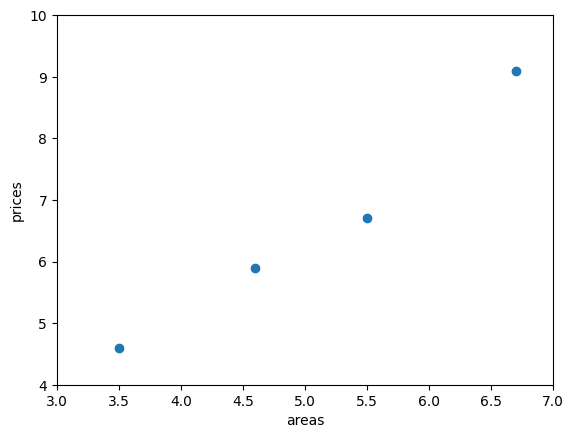

In [1]:
# load data

import numpy as np
from numpy import genfromtxt
import matplotlib.pyplot as plt

data = genfromtxt('data.csv', delimiter=',')
areas  = data[:,0]
prices = data[:,1:]
N = areas.size

print(type(areas))
print('areas: \n', areas)
print('prices: \n', prices)
print('data_size: ', N)

plt.scatter(areas, prices)
plt.xlabel('areas')
plt.ylabel('prices')
plt.xlim(3,7)
plt.ylim(4,10)
plt.show()

In [3]:
# vector [x, b]^T
data = np.vstack([areas, np.ones((N,))])
print('data \n', data)

theta = np.array([[-0.34], [0.04]]) #[w, b]
print('theta \n', theta)
print(theta.shape)

data 
 [[6.7 4.6 3.5 5.5]
 [1.  1.  1.  1. ]]
theta 
 [[-0.34]
 [ 0.04]]
(2, 1)


In [4]:
epoch_max = 10
m = 2
for epoch in range(epoch_max):
    for i in range(0, N, m): 
        
        # get m samples
        x = data[:, i:i+m]
        y = prices[i:i+m, :]
        
        print('x: \n', x)
        print('y: \n', y)
        
        break
    break

x: 
 [[6.7 4.6]
 [1.  1. ]]
y: 
 [[9.1]
 [5.9]]


In [22]:
import numpy as np
import matplotlib.pyplot as plt

data   = np.genfromtxt('data.csv', delimiter=',')
areas  = data[:,0]
prices = data[:,1:]
N = areas.size

# vector [x, b]^T
data = np.vstack([areas, np.ones((N,))])

 # [w, b]
theta = np.array([[-0.34], 
                  [0.04]])
                  
# params
lr = 0.01
epoch_max = 20
m = 2 

# logging
losses = [] 

for epoch in range(epoch_max):
    for i in range(0, N, m):
        # get m samples
        x = data[:, i:i+m]
        y = prices[i:i+m, :]
        
        # predict y_hat
        y_hat = theta.T.dot(x)
                
        # compute loss
        #loss = np.multiply((y_hat-y.T), (y_hat-y.T))
        #losses.append(np.mean(loss))
        loss = (1/m)*(y_hat-y.T).dot((y_hat-y.T).T)
        losses.append(loss[0][0])
        
        # compute gradient
        k = 2*(y_hat-y.T)
        gradients = np.multiply(np.vstack((k, k)), x)
        gradients = gradients.dot(np.ones((m, 1))) / m

        # update weights
        theta = theta - lr*gradients

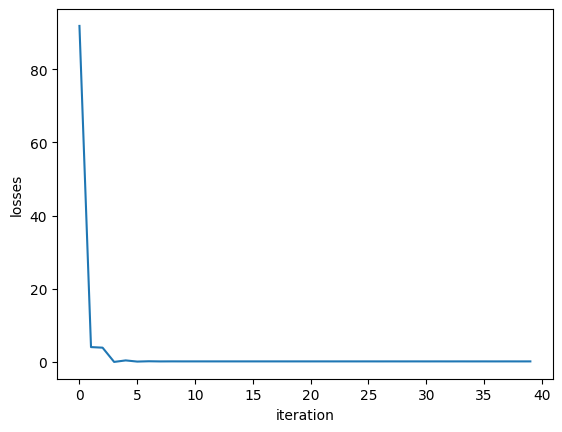

In [23]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel('iteration')
plt.ylabel('losses')
plt.show()

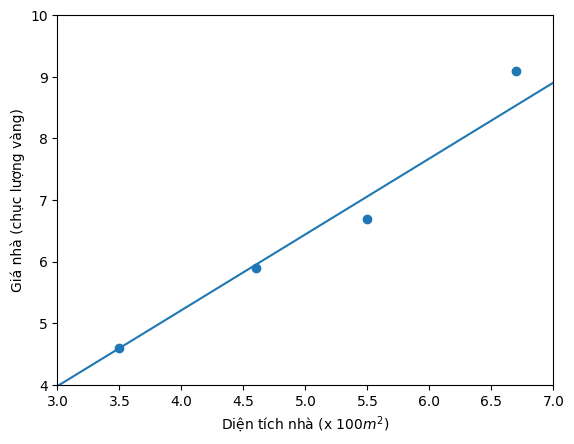

In [24]:
x_data = range(2, 8)
y_data = [x*theta[0] + theta[1] for x in x_data]
plt.plot(x_data, y_data)
#--------------------------------------
plt.scatter(areas, prices)

plt.xlabel('Diện tích nhà (x 100$m^2$)')
plt.ylabel('Giá nhà (chục lượng vàng)')

plt.xlim(3,7)
plt.ylim(4,10)
plt.show()

In [28]:
# using dot product

import numpy as np
import matplotlib.pyplot as plt

data   = np.genfromtxt('data.csv', delimiter=',')
areas  = data[:,0]
prices = data[:,1:]
N = areas.size

# vector [x, b]^T
data = np.vstack([areas, np.ones((N,))])

 # [w, b]
theta = np.array([[-0.34], 
                  [0.04]])
                  
# params
lr = 0.01
epoch_max = 20
m = 2 

# logging
losses = [] 

for epoch in range(epoch_max):
    for i in range(0, N, m):
        # get m samples
        x = data[:, i:i+m]
        y = prices[i:i+m, :]
        
        # predict y_hat
        y_hat = theta.T.dot(x)
                
        # compute loss
        #loss = np.multiply((y_hat-y.T), (y_hat-y.T))
        #losses.append(np.mean(loss))
        loss = (1/m)*(y_hat-y.T).dot((y_hat-y.T).T)
        losses.append(loss[0][0])
        
        # compute gradient
        k = 2*(y_hat-y.T)
        gradients = x.dot(k.T) / m   # here ----------

        # update weights
        theta = theta - lr*gradients

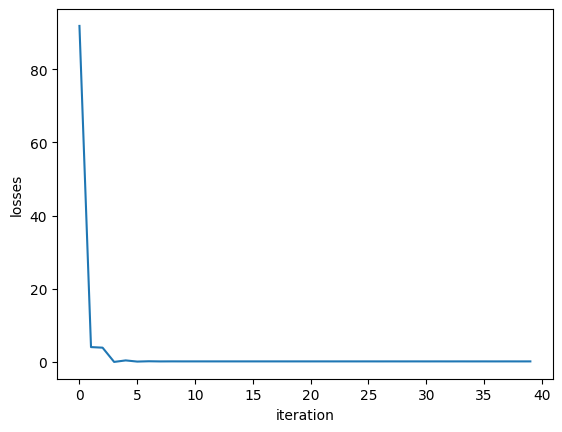

In [29]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel('iteration')
plt.ylabel('losses')
plt.show()

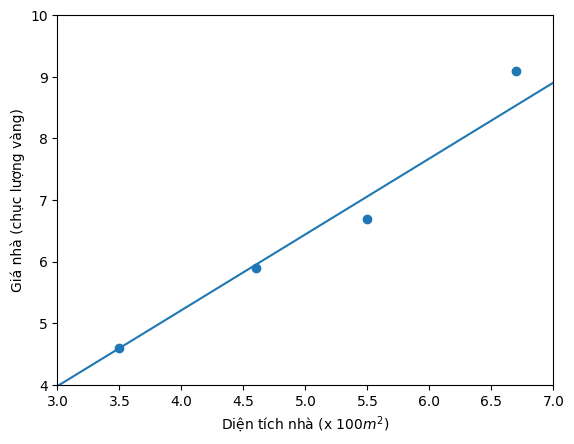

In [30]:
x_data = range(2, 8)
y_data = [x*theta[0] + theta[1] for x in x_data]
plt.plot(x_data, y_data)
#--------------------------------------
plt.scatter(areas, prices)

plt.xlabel('Diện tích nhà (x 100$m^2$)')
plt.ylabel('Giá nhà (chục lượng vàng)')

plt.xlim(3,7)
plt.ylim(4,10)
plt.show()

### Horizontal sample arrangement

In [12]:
import numpy as np
import matplotlib.pyplot as plt

data   = np.genfromtxt('data.csv', delimiter=',')
areas  = data[:,0:1]
prices = data[:,1:]
N = areas.size

# vector [x, b]
data = np.hstack([areas, np.ones((N,1))])

 # [w, b]
theta = np.array([[-0.34], 
                  [0.049]])

print(data)
print(theta)
print(prices)

[[6.7 1. ]
 [4.6 1. ]
 [3.5 1. ]
 [5.5 1. ]]
[[-0.34 ]
 [ 0.049]]
[[9.1]
 [5.9]
 [4.6]
 [6.7]]


In [13]:
# params
lr = 0.01
epoch_max = 20
m = 2 

# logging
losses = [] 

for epoch in range(epoch_max):
    for i in range(0, N, m):
        # get m samples
        x = data[i:i+m, :]
        y = prices[i:i+m, :]
        
        # predict y_hat
        y_hat = x.dot(theta)
                     
        # compute loss
        #loss = np.multiply((y_hat-y), (y_hat-y))
        #losses.append(np.mean(loss))
        loss = (1/m)*(y_hat-y).T.dot((y_hat-y))
        losses.append(loss[0][0])

        # compute gradient
        k = 2*(y_hat-y)
        gradients = k.T.dot(x) / m

        # update weights
        theta = theta - lr*gradients.T

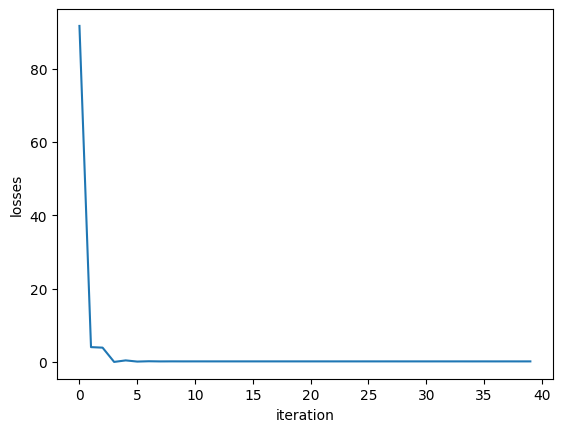

In [14]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel('iteration')
plt.ylabel('losses')
plt.show()

In [15]:
import numpy as np
import matplotlib.pyplot as plt

data   = np.genfromtxt('data.csv', delimiter=',')
areas  = data[:,0:1]
prices = data[:,1:]
N = areas.size

# vector [x, b]
data = np.hstack([areas, np.ones((N,1))])

 # [w, b]
theta = np.array([[-0.34], 
                  [0.049]])

print(data)
print(theta)
print(prices)

[[6.7 1. ]
 [4.6 1. ]
 [3.5 1. ]
 [5.5 1. ]]
[[-0.34 ]
 [ 0.049]]
[[9.1]
 [5.9]
 [4.6]
 [6.7]]


In [16]:
# params
lr = 0.01
epoch_max = 20
m = 2 

# logging
losses = [] 

for epoch in range(epoch_max):
    for i in range(0, N, m):
        # get m samples
        x = data[i:i+m, :]
        y = prices[i:i+m, :]
        
        # predict y_hat
        y_hat = x.dot(theta)
                     
        # compute loss
        #loss = np.multiply((y_hat-y), (y_hat-y))
        #losses.append(np.mean(loss))
        loss = (1/m)*(y_hat-y).T.dot((y_hat-y))
        losses.append(loss[0][0])
        
        # compute gradient
        k = 2*(y_hat-y)
        gradients = x.T.dot(k) / m

        # update weights
        theta = theta - lr*gradients

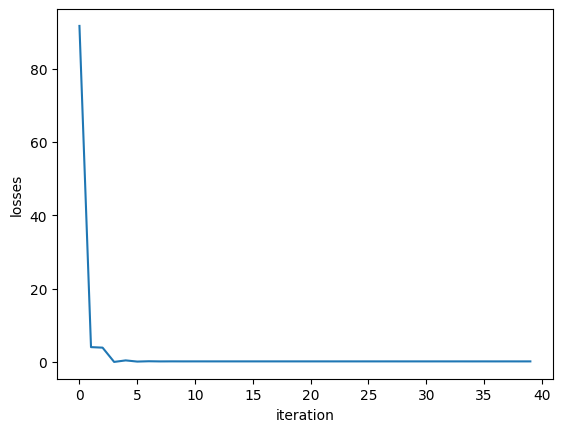

In [17]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel('iteration')
plt.ylabel('losses')
plt.show()

In [18]:
theta

array([[1.2301407 ],
       [0.29253171]])

0.2925317104358215 1.230140702568926


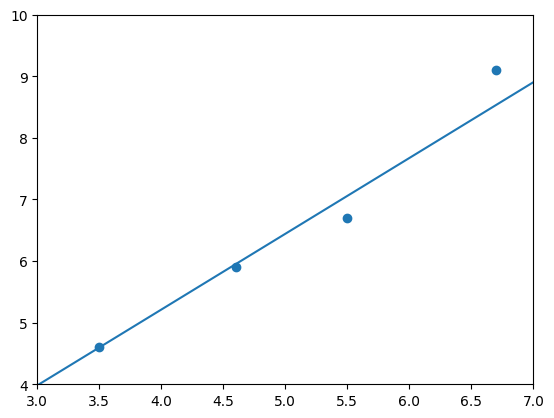

In [19]:
x_data = range(2, 8)

data   = np.genfromtxt('data.csv', delimiter=',')
areas  = data[:,0:1]
prices = data[:,1:]

predicted_w, predicted_b = theta[0, 0], theta[1, 0]
print(predicted_b, predicted_w)
y_data = [x*predicted_w + predicted_b for x in x_data]
plt.plot(x_data, y_data)
#--------------------------------------
plt.scatter(areas, prices)
plt.xlim(3,7)
plt.ylim(4,10)
plt.show()